In [15]:
import pandas as pd
from IPython.display import display, HTML
df = pd.read_csv('train.csv')

# 1. head, shape, info
display(HTML("<b>1. 5 Baris Pertama</b>")); display(df.head())
display(HTML(f"<b>2. Shape Dataset:</b> {df.shape[0]} baris, {df.shape[1]} kolom"))
display(HTML("<b>3. Info Dataset:</b>")); df.info()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [16]:
# 2. pembersihan data (missing values)
null_pct = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({'missing_count': df.isnull().sum(), 'percentage (%)': null_pct}).query('missing_count > 0').sort_values('percentage (%)', ascending=False)
display(HTML("<b>1. Atribut dengan Missing Value (Persentase)</b>")); display(missing_info)
# drop kolom > 50% missing
drop_cols = missing_info[missing_info['percentage (%)'] > 50].index.tolist()
df_clean = df.drop(columns=drop_cols).copy()
display(HTML(f"<b>2. Kolom Dihapus (>50% missing):</b> {drop_cols}"))
# imputasi tanpa warning (langsung assign df[col] = ...)
num_cols = df_clean.select_dtypes(include=['number']).columns
cat_cols = df_clean.select_dtypes(include=['object', 'category', 'string']).columns
for col in num_cols: df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in cat_cols: df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
display(HTML(f"<b>3. Sisa Missing Value Setelah Imputasi:</b> {df_clean.isnull().sum().sum()}"))

,missing_count,percentage (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


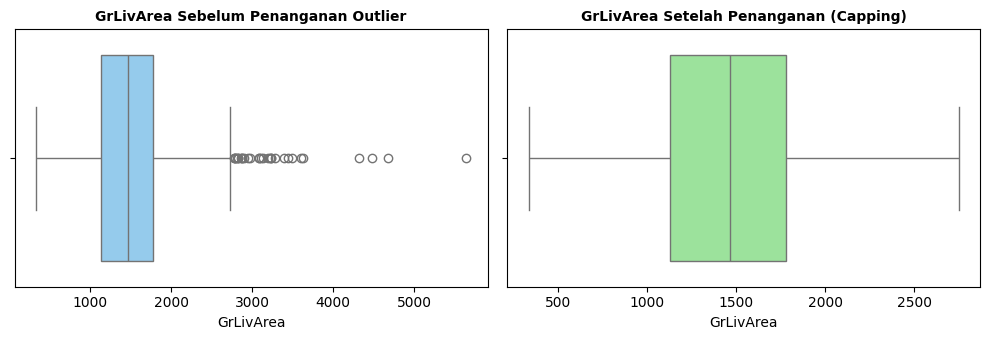

Outlier tidak dihapus (drop), melainkan disesuaikan menggunakan metode Capping (IQR Windsorization).
Alasannya: Pada dataset harga rumah (House Prices), baris data dengan ukuran rumah sangat luas (outlier) tetap mengandung informasi berharga untuk variabel lain. Menghapus baris akan mengurangi jumlah sampel data, sehingga batas ekstrim lebih aman disesuaikan ke batas atas (upper bound) IQR agar distribusi lebih stabil tanpa kehilangan baris data.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. deteksi & penanganan outlier (misal pada atribut numerik utama 'GrLivArea')
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
# boxplot sebelum capping
sns.boxplot(ax=axes[0], x=df_clean['GrLivArea'], color='lightskyblue')
axes[0].set_title('GrLivArea Sebelum Penanganan Outlier', fontsize=10, fontweight='bold')
# hitung IQR & capping outlier (diklip ke batas IQR agar data tidak terbuang)
Q1, Q3 = df_clean['GrLivArea'].quantile(0.25), df_clean['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
df_clean['GrLivArea'] = df_clean['GrLivArea'].clip(lower, upper)
# boxplot sesudah capping
sns.boxplot(ax=axes[1], x=df_clean['GrLivArea'], color='lightgreen')
axes[1].set_title('GrLivArea Setelah Penanganan (Capping)', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()
display(HTML("<b>Penjelasan Penanganan Outlier:</b>"))
print("Outlier tidak dihapus (drop), melainkan disesuaikan menggunakan metode Capping (IQR Windsorization).\nAlasannya: Pada dataset harga rumah (House Prices), baris data dengan ukuran rumah sangat luas (outlier) tetap mengandung informasi berharga untuk variabel lain. Menghapus baris akan mengurangi jumlah sampel data, sehingga batas ekstrim lebih aman disesuaikan ke batas atas (upper bound) IQR agar distribusi lebih stabil tanpa kehilangan baris data.")

In [18]:
from sklearn.preprocessing import StandardScaler

# 1. one-hot encoding untuk atribut kategorikal
cat_cols = df_clean.select_dtypes(include=['object', 'category', 'string']).columns
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
# 2. standarisasi (scaling) untuk atribut numerik (kecuali target 'SalePrice' dan 'Id' jika ada)
num_cols = df_clean.select_dtypes(include=['number']).columns.drop(['Id', 'SalePrice'], errors='ignore')
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
display(HTML("<b>1. Tipe Data Setelah Encoding & Scaling:</b>"))
display(HTML(f"Ukuran dataset awal: <b>{df_clean.shape}</b> &rarr; Ukuran setelah One-Hot Encoding: <b>{df_encoded.shape}</b>"))
display(HTML("<b>2. 5 Baris Pertama Data Hasil Transformasi:</b>"))
display(df_encoded.head())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,0.073375,-0.220875,-0.207142,0.651479,-0.517200,1.050994,0.878668,0.514104,0.575425,...,False,False,False,False,True,False,False,False,True,False
1,2,-0.872563,0.460320,-0.091886,-0.071836,2.179628,0.156734,-0.429577,-0.570750,1.171992,...,False,False,False,False,True,False,False,False,True,False
2,3,0.073375,-0.084636,0.073480,0.651479,-0.517200,0.984752,0.830215,0.325915,0.092907,...,False,False,False,False,True,False,False,False,True,False
3,4,0.309859,-0.447940,-0.096897,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.499274,...,False,False,False,False,True,False,False,False,False,False
4,5,0.073375,0.641972,0.375148,1.374795,-0.517200,0.951632,0.733308,1.366489,0.463568,...,False,False,False,False,True,False,False,False,True,False


In [19]:
import numpy as np
from sklearn.decomposition import PCA

# 1. identifikasi & drop atribut dengan korelasi sangat tinggi (> 0.85)
corr_matrix = df_encoded.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.85)]
df_reduced = df_encoded.drop(columns=high_corr_cols)
display(HTML(f"<b>1. Jumlah Kolom Dibuang (Korelasi > 0.85):</b> {len(high_corr_cols)} kolom"))
# 2. reduksi dimensi menggunakan PCA (mempertahankan 90% variansi data)
features = df_reduced.drop(columns=['SalePrice', 'Id'], errors='ignore')
pca = PCA(n_components=0.90)
features_pca = pca.fit_transform(features)
pca_cols = [f'PC{i+1}' for i in range(features_pca.shape[1])]
df_pca = pd.DataFrame(features_pca, columns=pca_cols)
display(HTML(f"<b>2. Reduksi Dimensi dengan PCA (90% Variansi):</b>"))
display(HTML(f"Jumlah atribut dari <b>{features.shape[1]}</b> dipangkas menjadi <b>{df_pca.shape[1]} Principal Components</b>"))
display(df_pca.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC34,PC35,PC36,PC37,PC38,PC39,PC40,PC41,PC42,PC43
0,2.121643,0.463225,2.015841,-1.957082,0.486660,-0.098173,1.393775,-1.123262,0.069299,-0.377192,...,0.146487,0.286749,0.137785,0.155842,-0.397500,0.190074,-0.126852,-0.008854,0.096173,-0.149304
1,-0.046207,-1.386634,-1.371750,-0.242581,-1.742014,-0.565009,0.009114,2.898905,-1.756006,-0.378184,...,0.102203,-0.407530,0.205449,-0.103768,0.692349,0.250100,-0.050815,0.247533,1.126578,0.445752
2,2.372818,0.292830,1.708595,-1.579547,-0.228831,-0.262508,-0.020158,-0.470303,0.169634,-0.740783,...,-0.010663,-0.188281,0.262457,0.085303,-0.256602,-0.587614,-0.677446,0.149643,0.229583,0.072241
3,-0.808562,1.523498,-0.648117,-0.268828,0.272487,2.567456,-0.162072,-1.584380,0.312047,-0.827438,...,-0.626404,0.737359,-1.175040,0.447629,0.023373,-0.530223,0.359843,-0.548978,-0.512880,-1.330162
4,4.677927,1.313127,0.233103,-1.533744,-0.102182,-0.511637,-0.242288,0.015057,-0.274262,-1.141597,...,0.540969,-0.126344,-0.023439,0.303090,0.045377,-0.040837,-0.055343,0.083598,0.139218,0.003744


In [20]:
output_csv = "5054251012_Catherine_Aprilia_Tugas_Praproses_Data.csv"
df_reduced.to_csv(output_csv, index=False)
print("Berhasil disimpan ke:", output_csv)

Berhasil disimpan ke: 5054251012_Catherine_Aprilia_Tugas_Praproses_Data.csv
